# ForecastLLM - Week 6 Day 4: First Learned Forecasting Model

This week - build a model that predicts future values from historical time-series data.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Baselines and Evaluation  
DAY 4: First Learned Forecasting Model  
DAY 5: Fine-tuning a Frontier Model  

## DAY 4: First Learned Forecasting Model

Today we train our first learned forecasting model and compare it with Day 3 baselines.


In [1]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from week6.data_loader import load_sample_series


In [2]:
TRAIN_FRACTION = 0.8
SEASONAL_PERIOD = 24

In [3]:
# Load and normalize to [timestamp, value]
USE_SYNTHETIC_FALLBACK = False

try:
    ts_df = load_sample_series()
except Exception as e:
    if not USE_SYNTHETIC_FALLBACK:
        raise
    from week6.data_loader import load_synthetic_series
    print(f"Loader failed ({e}); using explicit synthetic fallback")
    ts_df = load_synthetic_series(periods=240)

if not isinstance(ts_df, pd.DataFrame):
    raise TypeError(f"load_sample_series must return a pandas DataFrame, got {type(ts_df)}")
if not {"timestamp", "value"}.issubset(ts_df.columns):
    raise ValueError("Loaded dataframe must include 'timestamp' and 'value' columns")

ts_df = ts_df[["timestamp", "value"]].copy()
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)

if len(ts_df) < 120:
    raise RuntimeError(f"Need at least 120 rows, got {len(ts_df)}")

raw_split_idx = int(len(ts_df) * TRAIN_FRACTION)
train_df = ts_df.iloc[:raw_split_idx].copy()
test_df = ts_df.iloc[raw_split_idx:].copy()

print(f"Loaded {len(ts_df):,} rows")
print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")

Loaded 960 rows
Train rows: 768 | Test rows: 192


# Before we look at the learned model

We'll first rebuild forecasting baselines and metrics.

This keeps us honest: any learned model should beat these simple references.


In [4]:
# Note: evaluated test slice is exported later from plot_df.


In [ ]:
# Note: CSV readback is omitted here because export occurs after evaluation.


In [5]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-9, denom)
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / denom)


In [6]:
def evaluate_forecast(y_true, y_pred, model_name):
    frame = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).dropna()
    return {
        "model": model_name,
        "MAE": mean_absolute_error(frame["y_true"], frame["y_pred"]),
        "sMAPE": smape(frame["y_true"], frame["y_pred"]),
        "rows": len(frame),
    }


In [ ]:
# Baselines for one-step-ahead forecasting
# naive baseline: forecast equals lag_1 (most recent observed value)
# daily seasonal naive baseline: forecast equals lag_24
# weekly seasonal naive baseline would be lag_168 (only when that feature is included)

# And now - our first learned forecasting model

Lag features let regression "see" recent history in tabular form.

With these features, linear regression can serve as a simple learned baseline.


In [7]:
# Recreate supervised dataset with lag features
supervised_df = ts_df.copy()
supervised_df["lag_1"] = supervised_df["value"].shift(1)
supervised_df["lag_2"] = supervised_df["value"].shift(2)
supervised_df["lag_3"] = supervised_df["value"].shift(3)
supervised_df["lag_7"] = supervised_df["value"].shift(7)
supervised_df["lag_24"] = supervised_df["value"].shift(24)

LAG_COLUMNS = ["lag_1", "lag_2", "lag_3", "lag_7", "lag_24"]
if len(supervised_df) > 168:
    supervised_df["lag_168"] = supervised_df["value"].shift(168)
    LAG_COLUMNS.append("lag_168")

# calendar features (preserve week6 protocol)
supervised_df["day_of_week"] = supervised_df["timestamp"].dt.dayofweek
supervised_df["month"] = supervised_df["timestamp"].dt.month

# one-step-ahead target
target_col = "target"
supervised_df[target_col] = supervised_df["value"]

supervised_df = supervised_df.dropna().reset_index(drop=True)
supervised_df.head()

,timestamp,value,lag_1,lag_2,lag_3,lag_7,lag_24,lag_168,day_of_week,month,target
0,2000-01-08 00:00:00,13.5,13.7,14.3,15.2,19.4,13.5,12.8,5,1,13.5
1,2000-01-08 01:00:00,12.8,13.5,13.7,14.3,18.9,12.7,12.1,5,1,12.8
2,2000-01-08 02:00:00,12.3,12.8,13.5,13.7,18.0,12.3,11.6,5,1,12.3
3,2000-01-08 03:00:00,11.9,12.3,12.8,13.5,16.5,11.8,11.2,5,1,11.9
4,2000-01-08 04:00:00,11.6,11.9,12.3,12.8,15.2,11.4,10.8,5,1,11.6


In [8]:
FEATURE_COLUMNS = LAG_COLUMNS
MODEL_FEATURES = FEATURE_COLUMNS + ["day_of_week", "month"]

X = supervised_df[MODEL_FEATURES].copy()
y = supervised_df[target_col].copy()

### Evaluation protocol note

This notebook uses one-step-ahead rolling evaluation.

For each test timestamp, lag features may include previously observed actual values. This is valid for one-step-ahead forecasting, but it is not the same as a fixed-origin multi-step forecast.

Later notebooks may add recursive or rolling-origin evaluation.

In [9]:
# Chronological split for supervised learning (no shuffling)
split_idx = int(len(supervised_df) * TRAIN_FRACTION)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_supervised = supervised_df.iloc[split_idx:].copy()

# leakage sanity checks for this one-step-ahead setup
assert "value" not in MODEL_FEATURES
assert target_col not in MODEL_FEATURES
assert X_train.index.max() < X_test.index.min()
assert test_supervised["timestamp"].min() > supervised_df.iloc[split_idx - 1]["timestamp"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


X_train: (633, 8) X_test: (159, 8)
y_train: (633,) y_test: (159,)


In [10]:
# Linear Regression learns coefficients minimizing residual sum of squares
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)


In [11]:
trainable_params = len(MODEL_FEATURES) + 1
print(f"Model parameters (coefficients + intercept): {trainable_params}")
for feature, coef in zip(MODEL_FEATURES, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"intercept: {model.intercept_:.4f}")


Model parameters (coefficients + intercept): 9
lag_1: 0.1470
lag_2: -0.0989
lag_3: 0.0179
lag_7: 0.0020
lag_24: 0.9354
lag_168: -0.0001
day_of_week: -0.0004
month: 0.1198
intercept: -0.0002


In [12]:
def linear_regression_forecast(row):
    return model.predict(pd.DataFrame([row[MODEL_FEATURES]]))[0]


In [13]:
lr_example = linear_regression_forecast(test_supervised.iloc[0])
print(f"Example LR forecast: {lr_example:.3f}")

Example LR forecast: 21.015


These baselines are evaluated on the same supervised test rows as the learned model, so all models receive the same information set.

# Baselines remain critical

Even a learned model can underperform simple methods.

So we evaluate naive (`lag_1`) and daily seasonal naive (`lag_24`) on the exact same test window.

In [14]:
# One-step naive baseline using lag_1 from each supervised test row
naive_pred = test_supervised["lag_1"].to_numpy()

# One-step seasonal naive baseline using lag_24 from each supervised test row
seasonal_naive_pred = test_supervised["lag_24"].to_numpy()


In [15]:
results = [
    evaluate_forecast(y_test, naive_pred, "naive"),
    evaluate_forecast(y_test, seasonal_naive_pred, "seasonal_naive"),
    evaluate_forecast(y_test, y_pred_lr, "linear_regression"),
]
results_df = pd.DataFrame(results)
results_df

,model,MAE,sMAPE,rows
0,naive,0.765409,3.602139,159
1,seasonal_naive,0.144654,0.682036,159
2,linear_regression,0.175620,0.817507,159


In [16]:
# ranked by forecasting error
results_df.sort_values(["MAE", "sMAPE"]).reset_index(drop=True)

,model,MAE,sMAPE,rows
0,seasonal_naive,0.144654,0.682036,159
1,linear_regression,0.175620,0.817507,159
2,naive,0.765409,3.602139,159


# Chronological comparison plot

Chronological evaluation matters because forecasting should mimic real deployment:
we predict future observations from past observations only.


In [17]:
plot_df = pd.DataFrame({
    "timestamp": test_supervised["timestamp"].to_numpy(),
    "actual": y_test.to_numpy(),
    "naive": naive_pred,
    "seasonal_naive": seasonal_naive_pred,
    "linear_regression": y_pred_lr,
})
plot_df.head()

plot_df.to_csv("day4_test_slice.csv", index=False)
print("Saved day4_test_slice.csv")


Saved day4_test_slice.csv


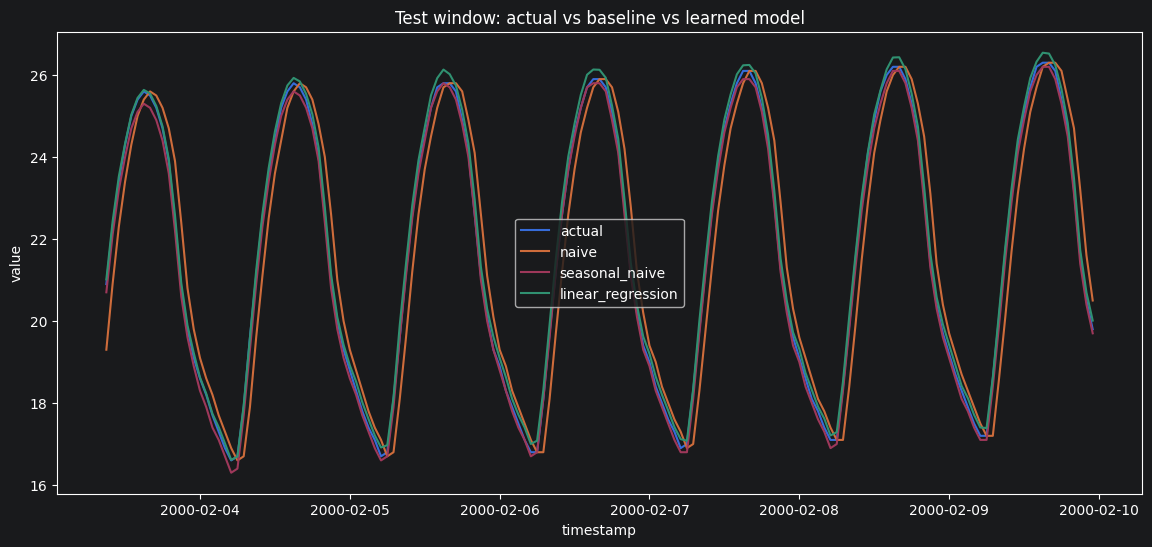

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(plot_df["timestamp"], plot_df["actual"], label="actual")
plt.plot(plot_df["timestamp"], plot_df["naive"], label="naive")
plt.plot(plot_df["timestamp"], plot_df["seasonal_naive"], label="seasonal_naive")
plt.plot(plot_df["timestamp"], plot_df["linear_regression"], label="linear_regression")
plt.title("Test window: actual vs baseline vs learned model")
plt.xlabel("timestamp")
plt.ylabel("value")
plt.legend()
plt.show()


In [19]:
# inspect first few rows numerically
print(plot_df.head(10).to_string(index=False))

          timestamp  actual  naive  seasonal_naive  linear_regression
2000-02-03 09:00:00    20.9   19.3            20.7          21.014510
2000-02-03 10:00:00    22.3   20.9            22.1          22.423580
2000-02-03 11:00:00    23.4   22.3            23.2          23.527854
2000-02-03 12:00:00    24.3   23.4            24.0          24.327218
2000-02-03 13:00:00    25.0   24.3            24.7          25.030751
2000-02-03 14:00:00    25.4   25.0            25.1          25.441106
2000-02-03 15:00:00    25.6   25.4            25.3          25.637104
2000-02-03 16:00:00    25.5   25.6            25.2          25.549196
2000-02-03 17:00:00    25.2   25.5            24.9          25.244135
2000-02-03 18:00:00    24.7   25.2            24.4          24.748082


In [20]:
# absolute error comparison
error_df = pd.DataFrame({
    "timestamp": plot_df["timestamp"],
    "naive_abs_error": np.abs(plot_df["actual"] - plot_df["naive"]),
    "seasonal_naive_abs_error": np.abs(plot_df["actual"] - plot_df["seasonal_naive"]),
    "linear_regression_abs_error": np.abs(plot_df["actual"] - plot_df["linear_regression"]),
})
error_df.describe()

,timestamp,naive_abs_error,seasonal_naive_abs_error,linear_regression_abs_error
count,159,159.000000,159.000000,159.000000
mean,2000-02-06 16:00:00,0.765409,0.144654,0.175620
min,2000-02-03 09:00:00,0.000000,0.000000,0.003015
25%,2000-02-05 00:30:00,0.400000,0.100000,0.123785
50%,2000-02-06 16:00:00,0.700000,0.100000,0.200352
75%,2000-02-08 07:30:00,1.200000,0.200000,0.224571
max,2000-02-09 23:00:00,1.700000,0.300000,0.365031
std,NaN,0.496824,0.079275,0.078588


In [21]:
best_model = results_df.sort_values(["MAE", "sMAPE"]).iloc[0]["model"]
print(f"Best current model: {best_model}")

Best current model: seasonal_naive


In [22]:
# TODO: rolling-origin evaluation
rolling_origin_planned = True
print(f"Rolling-origin evaluation planned: {rolling_origin_planned}")

Rolling-origin evaluation planned: True


In [23]:
# TODO: multi-series (M4)
multi_series_planned = True
print(f"Multi-series M4 extension planned: {multi_series_planned}")

Multi-series M4 extension planned: True


In [24]:
# TODO: stronger models (tree-based, etc.)
next_models = ["random_forest", "gradient_boosting", "xgboost_if_needed"]
print("Potential next models:", next_models)


Potential next models: ['random_forest', 'gradient_boosting', 'xgboost_if_needed']


In [25]:
artifacts = {
    "features": MODEL_FEATURES,
    "target": target_col,
    "rows": {"train": len(X_train), "test": len(X_test)},
    "metrics": results_df.to_dict(orient="records"),
}
artifacts

{'features': ['lag_1',
  'lag_2',
  'lag_3',
  'lag_7',
  'lag_24',
  'lag_168',
  'day_of_week',
  'month'],
 'target': 'target',
 'rows': {'train': 633, 'test': 159},
 'metrics': [{'model': 'naive',
   'MAE': 0.7654088050314466,
   'sMAPE': 3.6021390654719125,
   'rows': 159},
  {'model': 'seasonal_naive',
   'MAE': 0.1446540880503145,
   'sMAPE': 0.6820358748363368,
   'rows': 159},
  {'model': 'linear_regression',
   'MAE': 0.17562041244104828,
   'sMAPE': 0.8175066506346754,
   'rows': 159}]}

In [26]:
print("Final comparison table")
print(results_df[["model", "MAE", "sMAPE", "rows"]].to_string(index=False))

Final comparison table
            model      MAE    sMAPE  rows
            naive 0.765409 3.602139   159
   seasonal_naive 0.144654 0.682036   159
linear_regression 0.175620 0.817507   159


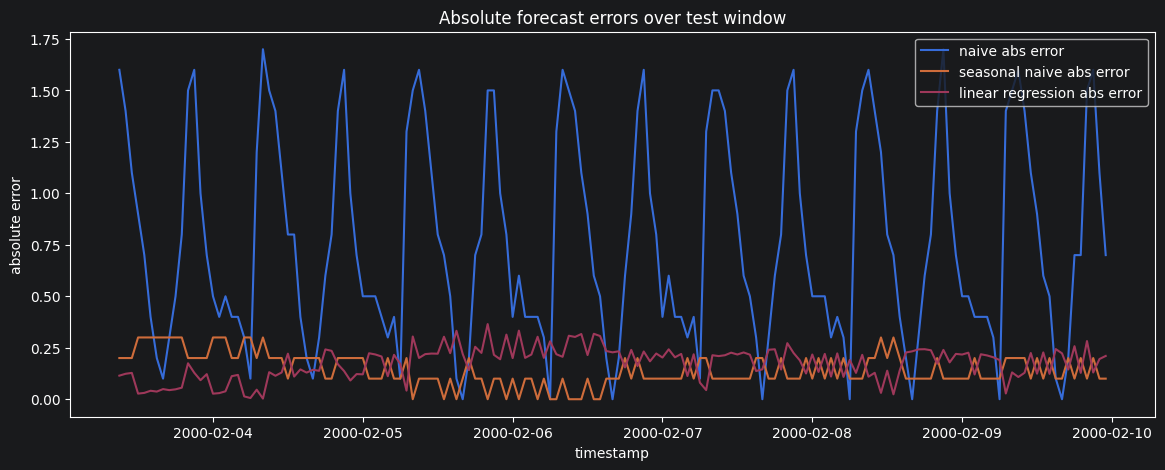

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(error_df["timestamp"], error_df["naive_abs_error"], label="naive abs error")
plt.plot(error_df["timestamp"], error_df["seasonal_naive_abs_error"], label="seasonal naive abs error")
plt.plot(error_df["timestamp"], error_df["linear_regression_abs_error"], label="linear regression abs error")
plt.title("Absolute forecast errors over test window")
plt.xlabel("timestamp")
plt.ylabel("absolute error")
plt.legend()
plt.show()


In [28]:
# quick residual summary for the learned model
lr_residuals = plot_df["actual"] - plot_df["linear_regression"]
print(lr_residuals.describe())

count    159.000000
mean      -0.175547
std        0.078752
min       -0.365031
25%       -0.224571
50%       -0.200352
75%       -0.123785
max        0.005824
dtype: float64


In [29]:
# package final frame for later notebooks
final_forecast_frame = plot_df.copy()
final_forecast_frame.head(3)

,timestamp,actual,naive,seasonal_naive,linear_regression
0,2000-02-03 09:00:00,20.9,19.3,20.7,21.014510
1,2000-02-03 10:00:00,22.3,20.9,22.1,22.423580
2,2000-02-03 11:00:00,23.4,22.3,23.2,23.527854


In [30]:
print("Day 4 completed: first learned model compared to Day 3 baselines.")

Day 4 completed: first learned model compared to Day 3 baselines.
